# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☒ Standard Analysis ☐ Research-Oriented  
**Group Number:** 16 </br>
**Group members:**  
- Giancarlo Marchesini  
- Himan Kalita 
- Kris Kraack

## Task Description

**Objective (Module 2 perspective)**
Using the Bike Sharing Dataset (2011-2012), this module models daily records as a graph to analyse demand structure from a graph perspective. Each node represents one day, and edges connect days with similar weather and calendar context conditions. The objective is to identify recurring day types and explain their behavioral meaning using post-hoc demand attributes.

**Research question**
Can a day-level similarity graph reveal a small and meaningful set of recurring day types that differ in total demand, rider composition, and weather/calendar context?

**Hypotheses**
- **H1 (structural):** Days with similar weather and calendar conditions form coherent graph communities.
- **H2 (behavioral):** The detected communities show clear differences in total bike rentals (`cnt`) and rider composition between casual riders (`casual`) and registered riders (`registered`).
- **H3 (interpretability):** The graph communities can be interpreted as practical demand regimes (e.g., commuter-dominant vs leisure-dominant day types), rather than arbitrary partitions.

## 0. Reproducibility and Setup

In [1]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN



RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.11.10 | packaged by conda-forge | (main, Oct 16 2024, 01:17:14) [MSC v.1941 64 bit (AMD64)]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Dataset: Bike Sharing Dataset (2011–2012)
- Reference: Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.
- Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- Number of instances: 
    - 'hour.csv' : 17379;
    - 'day.csv' : 731.
- Number of features / entities: 
    - 'hour.csv' : 17;
    - 'day.csv' : 16.
- Missing values: The dataset doesn't have missing values.
- Basic statistics: See section below.


**Dataset characteristics** </br> 
Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv
- instant: record index
- dteday : date
- season : season (1:springer, 2:summer, 3:fall, 4:winter)
- yr : year (0: 2011, 1:2012)
- mnth : month ( 1 to 12)
- hr : hour (0 to 23)
- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
- weekday : day of the week
- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
+ weathersit : 
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp : Normalized temperature in Celsius. The values are divided to 41 (max)
- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- hum: Normalized humidity. The values are divided to 100 (max)
- windspeed: Normalized wind speed. The values are divided to 67 (max)
- casual: count of casual users
- registered: count of registered users
- cnt: count of total rental bikes including both casual and registered
	

In [2]:
# Load dataset
data_day  = pd.read_csv('data/day.csv')  # day csv file
data_hour = pd.read_csv('data/hour.csv') # hour csv file

# Print dataset(s) shapes (r,c)
print(f"day dataset - shape: {data_day.shape}") #day
print(f"hour dataset - shape: {data_hour.shape}") #hour

# Print missing values (NaNs)
print("day dataset - NaNs:", data_day.isnull().sum().sum()) 
print("hour dataset - NaNs:", data_hour.isnull().sum().sum())

# Inspect 
#data_hour.head(5)
data_day.head(5)

day dataset - shape: (731, 16)
hour dataset - shape: (17379, 17)
day dataset - NaNs: 0
hour dataset - NaNs: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Exploratory Data Analysis

#### Basic statistics

In [3]:
# Basic statistics: Day
day_stats = (
    data_day.select_dtypes(include='number')
            .describe()
            .T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
            .round(3)
)
print("Basic statistics: Day:")
display(day_stats)

# Basic statistics: hour
hour_stats = (
    data_hour.select_dtypes(include='number')
             .describe()
             .T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
             .round(3)
)
print("Basic statistics: Hour")
display(hour_stats)

Basic statistics: Day:


,count,mean,std,min,25%,50%,75%,max
instant,731.0,366.000,211.166,1.000,183.500,366.000,548.500,731.000
season,731.0,2.497,1.111,1.000,2.000,3.000,3.000,4.000
yr,731.0,0.501,0.500,0.000,0.000,1.000,1.000,1.000
mnth,731.0,6.520,3.452,1.000,4.000,7.000,10.000,12.000
holiday,731.0,0.029,0.167,0.000,0.000,0.000,0.000,1.000
weekday,731.0,2.997,2.005,0.000,1.000,3.000,5.000,6.000
workingday,731.0,0.684,0.465,0.000,0.000,1.000,1.000,1.000
weathersit,731.0,1.395,0.545,1.000,1.000,1.000,2.000,3.000
temp,731.0,0.495,0.183,0.059,0.337,0.498,0.655,0.862
atemp,731.0,0.474,0.163,0.079,0.338,0.487,0.609,0.841


Basic statistics: Hour


,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000,5017.029,1.00,4345.500,8690.000,13034.500,17379.000
season,17379.0,2.502,1.107,1.00,2.000,3.000,3.000,4.000
yr,17379.0,0.503,0.500,0.00,0.000,1.000,1.000,1.000
mnth,17379.0,6.538,3.439,1.00,4.000,7.000,10.000,12.000
hr,17379.0,11.547,6.914,0.00,6.000,12.000,18.000,23.000
holiday,17379.0,0.029,0.167,0.00,0.000,0.000,0.000,1.000
weekday,17379.0,3.004,2.006,0.00,1.000,3.000,5.000,6.000
workingday,17379.0,0.683,0.465,0.00,0.000,1.000,1.000,1.000
weathersit,17379.0,1.425,0.639,1.00,1.000,1.000,2.000,4.000
temp,17379.0,0.497,0.193,0.02,0.340,0.500,0.660,1.000


#### Correlation Heatmap

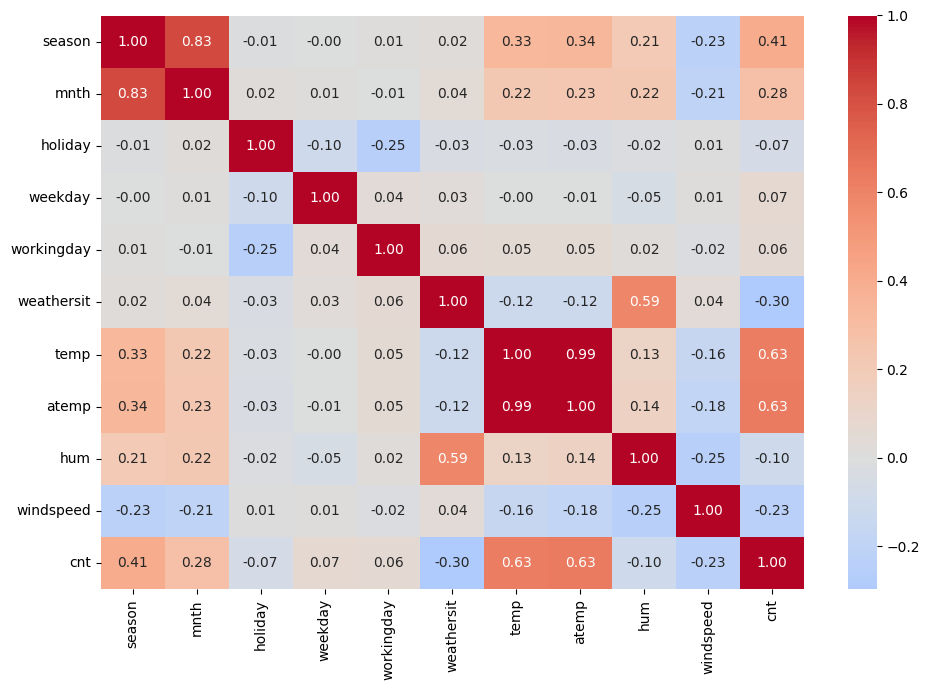

In [4]:
# Correlation heatmap using day data
# Select columns
columns = ['season', 'mnth', 'holiday', 'weekday', 'workingday',
             'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(data_day[columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

#### Distributions

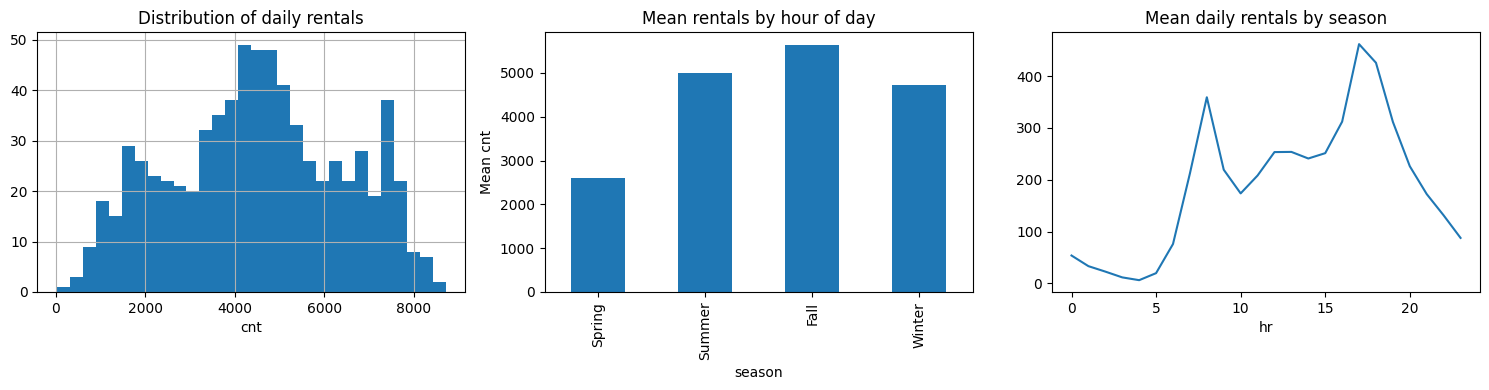

In [5]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# daily rentals
data_day['cnt'].hist(ax=axes[0], bins=30)
axes[0].set_title('Distribution of daily rentals')
axes[0].set_xlabel('cnt')

# daily rentals (hour)
data_hour.groupby('hr')['cnt'].mean().plot(ax=axes[2])
axes[1].set_title('Mean rentals by hour of day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Mean cnt')

# Seasons (mean)
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
data_day.groupby('season')['cnt'].mean().rename(season_labels).plot(
    kind='bar', ax=axes[1])
axes[2].set_title('Mean daily rentals by season')

# Plot
plt.tight_layout()
plt.show()

#### Density

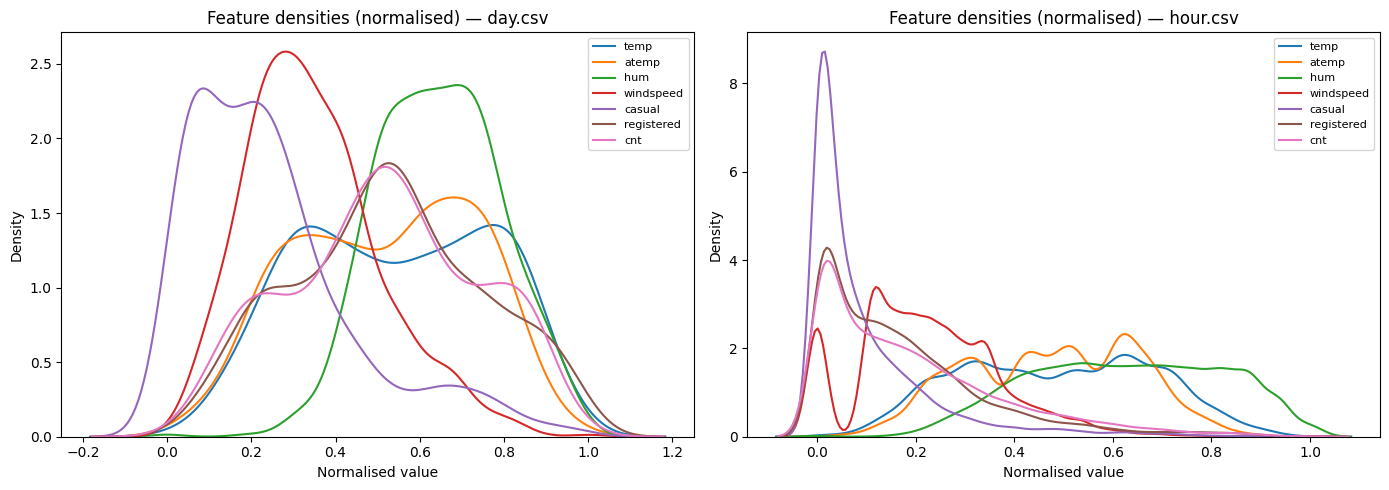

In [6]:
# KDE Density plots for selected continuous entries  (normalised)
columns_of_int  = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Plot Density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# day
for col in columns_of_int:
    vals = data_day[col]
    sns.kdeplot((vals - vals.min()) / (vals.max() - vals.min()),
                ax=axes[0], label=col, fill=False)
axes[0].set_title('Feature densities (normalised) — day.csv')
axes[0].set_xlabel('Normalised value')
axes[0].legend(fontsize=8)

# hour
for col in columns_of_int:
    vals = data_hour[col]
    sns.kdeplot((vals - vals.min()) / (vals.max() - vals.min()),
                ax=axes[1], label=col, fill=False)
axes[1].set_title('Feature densities (normalised) — hour.csv')
axes[1].set_xlabel('Normalised value')
axes[1].legend(fontsize=8)


plt.tight_layout()
plt.show()


## 2. Module 1 — Vector-Space Analysis

#### Feature engineering
Selected based on the correlation heatmap and the task definition

In [7]:
# Define the features for clustering: Selected based on the correlation heatmap 
features = ['temp', 'hum', 'windspeed', 'weathersit', 'season', 'workingday', 'cnt']

### 2.1 Vector Representation

**Feature vector:** Each day is represented by 7 features selected based on the correlation heatmap and task defintion.

| Feature | Type | Intuition |
|---|---|---|
| `temp` | continuous (normalised) | Strong positive correlation with `cnt` |
| `hum` | continuous (normalised) | Moderate negative correlation with `cnt` |
| `windspeed` | continuous (normalised) | Mild negative effect on ridership |
| `weathersit` | ordinal (1–4) | Captures weather severity |
| `season` | ordinal (1–4) | Seasonal demand variation |
| `workingday` | binary (0/1) | Commuter vs leisure usage patters |
| `cnt` | continuous (count) | Total demand: key signal |

**Preprocessing:** All features are standardised to zero mean and unit variance (`StandardScaler`) so that features with different scales contribute equally to the Euclidean distance.

**Distance measure:** Euclidean distance (default for K-Means).

In [8]:
# Construct vector representation
X = StandardScaler().fit_transform(data_day[features])  # Replace with actual feature matrix (standardised to zero mean and unit variance =  features with different scales contribute equally the Euclidean distance)

# Print shape
print(f"Feature matrix shape: {X.shape}") 

# Distance measure: We use euclidean distance (default for K-Means)

Feature matrix shape: (731, 7)


### 2.2 Clustering Method

### Method 1: K-Means/K-Means++

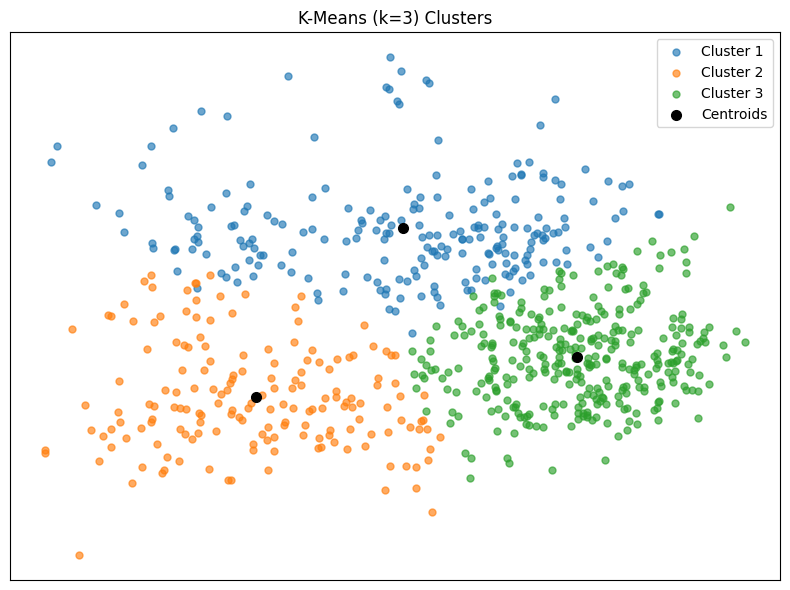

          temp    hum  windspeed  weathersit  season  workingday       cnt
cluster                                                                   
1        0.472  0.768      0.192       2.086   2.600       0.718  3764.468
2        0.308  0.498      0.236       1.170   1.345       0.637  2898.292
3        0.605  0.603      0.166       1.062   3.009       0.685  5790.847


In [9]:
# Implement clustering algorithm here: Method 1 (K-means): Manual without any parameter tuning
# Inititilze K and setup K-means (scikit learn) 
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_SEED, n_init=35)
labels = kmeans.fit_predict(X)

# Using PCA for 2D plots
pca = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
cents = PCA(n_components=2, random_state=RANDOM_SEED).fit(X).transform(kmeans.cluster_centers_)

# Plots clusters
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(K):
    ax.scatter(*pca[labels == c].T, s=25, alpha=0.65, label=f'Cluster {c+1}')
ax.scatter(*cents.T, s=49, marker='o', c='black', zorder=5, label='Centroids')
ax.set(title=f'K-Means (k={K}) Clusters',)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(); plt.tight_layout(); plt.show()

# Print cluster profiles (mean values of selected features) 
print(data_day[features].assign(cluster=labels+1).groupby('cluster').mean().round(3))

#### Parameter search

In [10]:
# grid search over K-Means & K-Means++ hyperparameters: Using silhouette as evaluation method
# References:
# https://stackoverflow.com/questions/34611038/grid-search-for-hyperparameter-evaluation-of-clustering-in-scikit-learn
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html#
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
# https://farshadabdulazeez.medium.com/understanding-silhouette-score-in-clustering-8aedc06ce9c4
h_params = {
    'n_clusters': range(2, 10),
    'init': ['k-means++', 'random'],
    'n_init': [10]
}

# Gridsearch 
r = []
for p in ParameterGrid(h_params):
    kmeans = KMeans(random_state=RANDOM_SEED, **p)
    labels_k = kmeans.fit_predict(X)
    r.append({
        'k': p['n_clusters'],
        'init': p['init'],
        'silhouette': silhouette_score(X, labels_k),
        'inertia': kmeans.inertia_
    })

# Generate df with grid results 
grid_results = pd.DataFrame(r).sort_values(
    ['silhouette', 'inertia'],
    ascending=[False, True]
).reset_index(drop=True)

# show results
display(grid_results)

# Print best
print(f"Best: k={int(grid_results.loc[0, 'k'])}, method='{grid_results.loc[0, 'init']}', silhouette={float(grid_results.loc[0, 'silhouette']):.4f}")

,k,init,silhouette,inertia
0,2,k-means++,0.244613,3956.964456
1,2,random,0.244187,3956.969263
2,8,k-means++,0.242119,2107.353340
3,8,random,0.241977,2106.821046
4,9,k-means++,0.241298,1971.180281
5,9,random,0.239441,1972.560751
6,6,random,0.227104,2429.992502
7,3,random,0.226541,3280.320363
8,3,k-means++,0.226384,3280.229387
9,7,k-means++,0.225761,2261.193680


Best: k=2, method='k-means++', silhouette=0.2446


The highest silhouette score is obtained at `k=2` with `k-means++`, which seems to be a very coarse split. Second best segmentation `k=8` with  `k-means++` is the strongest alternative and might be more informative.

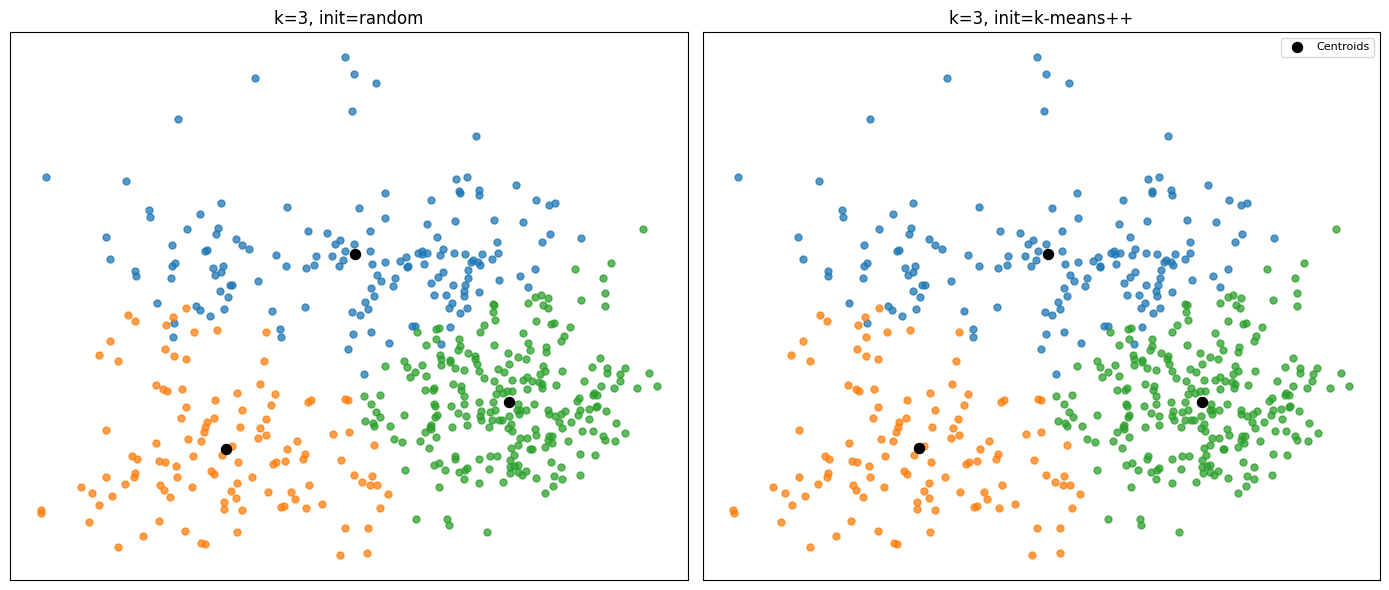

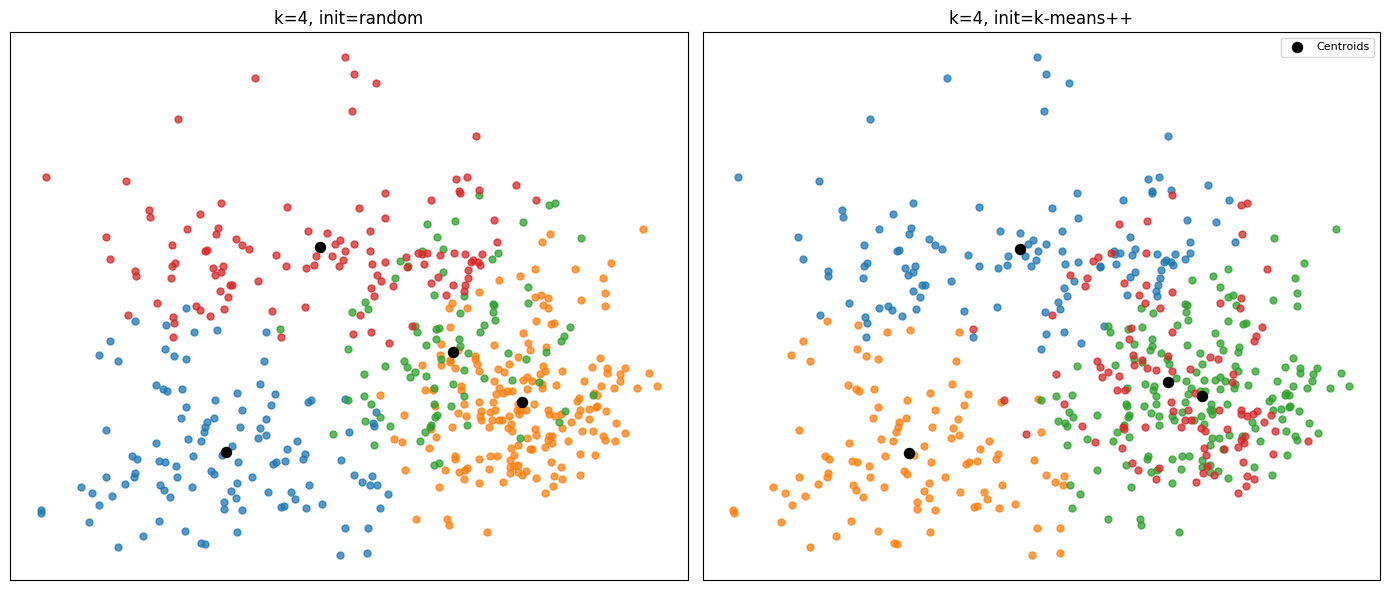

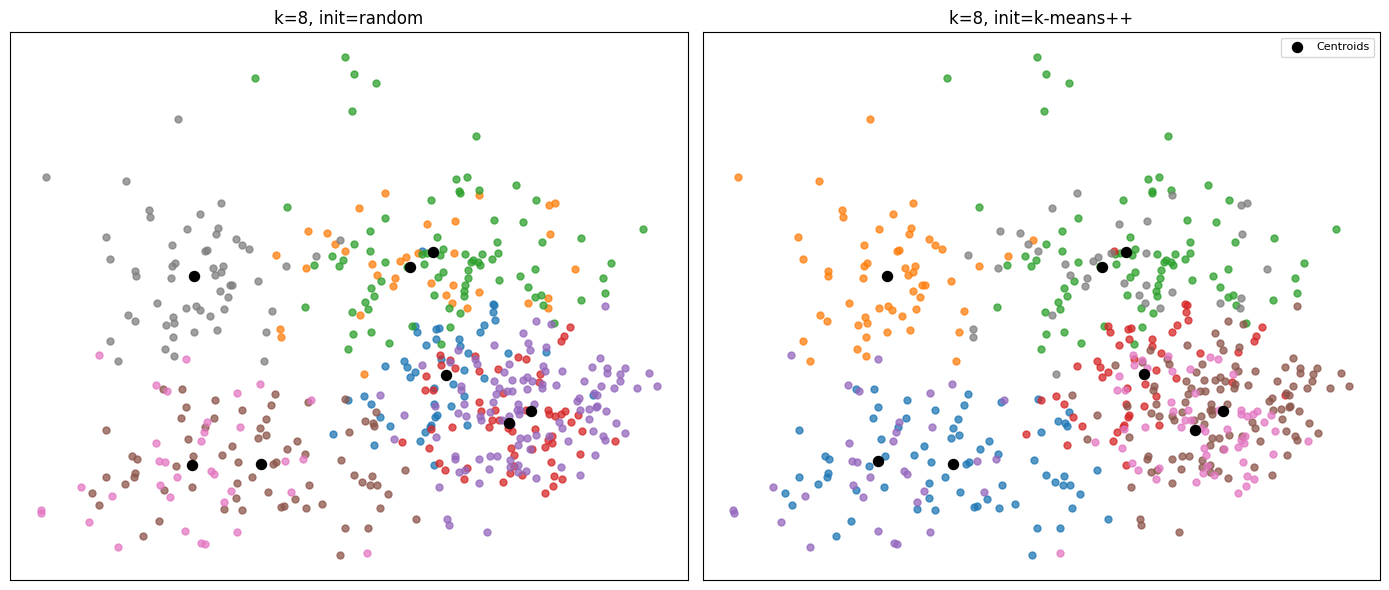

In [11]:
# Implement clustering algorithm here: Method 1 (K-means): Manual without any parameter tuning
# Inititilze K and setup K-means (scikit learn) 
k_values = [3, 4, 8]
init_opts = ['random', 'k-means++']

pca= PCA(n_components=2, random_state=RANDOM_SEED).fit(X)
pca_t = pca.transform(X)

# Use a fixed sample for cleaner visuals while keeping comparisons fair
sample  = np.random.default_rng(RANDOM_SEED)
sample_n = min(500, pca_t.shape[0])
sample_idx = sample.choice(pca_t.shape[0], size=sample_n, replace=False)

# Plots clusters: side-by-side figure per k value
for k in k_values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    for ax, init in zip(axes, init_opts):
        km = KMeans(n_clusters=k, init=init, random_state=RANDOM_SEED, n_init=10)
        labels = km.fit_predict(X)
        cents = pca.transform(km.cluster_centers_)
        for c in range(k):
            m = (labels == c)
            m_sample = m & np.isin(np.arange(len(labels)), sample_idx)
            ax.scatter(*pca_t[m_sample].T, s=25, alpha=0.75)
        ax.scatter(*cents.T, s=52, marker='o', c='black', zorder=6, label='Centroids')
        ax.set_title(f'k={k}, init={init}', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[1].legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

### Method 1: Discussion

From the K-Means plots, `k=3` looks the cleanest and most interpretable, while `k=4` is a reasonable only for K-Means. `k=8` appears very over-segmented.

The K-Means clusters are somewhat usable for summarising broad daily patterns, but they are not strongly separated. Meaning that they are therefore likely most useful for interpretation, and not as strong evidence of naturally distinct clusters.

### Method 2: DBSCAN

#### Feature engineering

In [12]:
# Select base features
features = ['temp', 'windspeed', 'workingday', 'casual', 'registered']

# Log transform count variables to reduce skewness
data_day['casual_log'] = np.log1p(data_day['casual'])
data_day['registered_log'] = np.log1p(data_day['registered'])

# Construct the feature matrix with transformed counts
X = data_day[['temp', 'windspeed', 'workingday', 'casual_log', 'registered_log']]

# Standardize features so each contributes equally to distance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Plot the k-distance graph to choose epsilon for DBSCAN

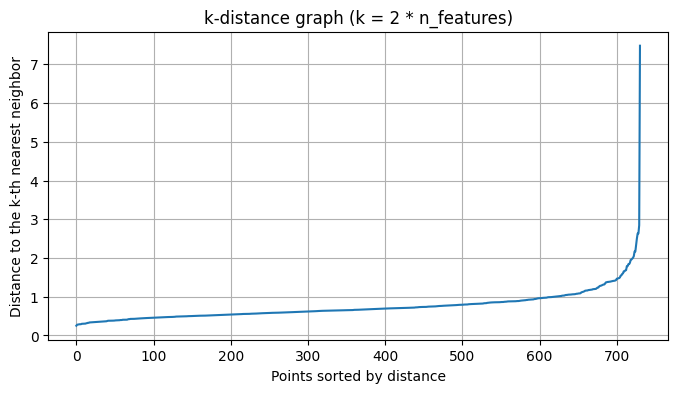

In [13]:
# Plot the k-distance graph to choose eps for DBSCAN
# Set min_samples as twice the number of features
min_samples_estimate = 2 * X.shape[1]

neighbors = NearestNeighbors(n_neighbors=int(min_samples_estimate))
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, int(min_samples_estimate) - 1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('k-distance graph (k = 2 * n_features)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to the k-th nearest neighbor')
plt.grid(True)
plt.show()

# After plotting, inspect the curve for an elbow point.  This value of distance
# will be used as the eps parameter for DBSCAN.

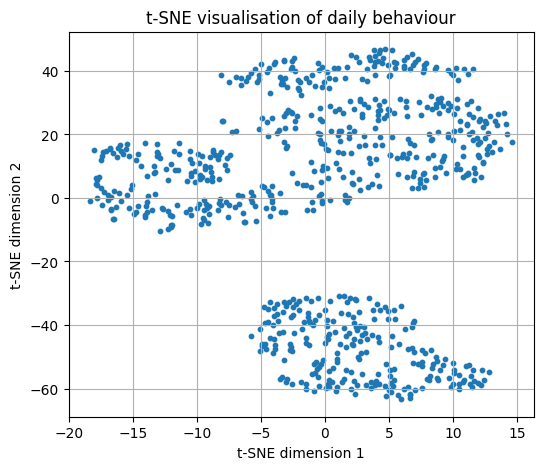

In [14]:
# Perform t-SNE to visualise potential clusters
# Use a moderate perplexity.  t-SNE is stochastic; random_state ensures reproducibility.
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10)
plt.title('t-SNE visualisation of daily behaviour')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True)
plt.show()

# Look for visually separated clusters.  If distinct clouds appear, DBSCAN is likely appropriate.

#### Choosing DBSCAN parameters

The DBSCAN algorithm requires two key parameters:

- **`eps` (epsilon)** – defines the radius of the neighborhood for clustering.  Use the elbow point from the k-distance graph as a guideline for choosing `eps`.The epsilon parameter was selected from the k-distance graph by identifying the elbow point at approximately 1.4, which represents the transition from dense regions to sparse regions.
- **`min_samples`** – minimum number of points required to form a dense region.  A common heuristic is to set `min_samples` to twice the number of features; in this case, that is 10.  You may adjust it based on domain knowledge.

After examining the k-distance plot, set `eps` in the next cell and run the clustering.  Note that changing `eps` or `min_samples` will affect the number and composition of clusters.


In [15]:
# Apply DBSCAN clustering
from sklearn.cluster import DBSCAN

# TODO: Replace the value below with your chosen eps from the k-distance graph.
eps_value = 1.4  # <-- Set your chosen epsilon here
min_samples_value = int(2 * X.shape[1])  # default to 2 * n_features

# Fit DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

# Assign cluster labels back to the data
data_day['cluster'] = labels

# Summarise cluster sizes (including noise labelled as -1)
cluster_counts = data_day['cluster'].value_counts()
print('Cluster counts (including noise):')
print(cluster_counts)

# Compute mean values of key variables per cluster
summary = data_day.groupby('cluster')[['temp', 'windspeed', 'casual', 'registered']].mean()
print('Cluster summaries (mean values):')
print(summary)

Cluster counts (including noise):
cluster
 1    494
 0    226
-1     11
Name: count, dtype: int64
Cluster summaries (mean values):
             temp  windspeed       casual   registered
cluster                                               
-1       0.285725   0.301096   107.727273   686.000000
 0       0.484783   0.188015  1397.300885  3003.323009
 1       0.504904   0.189154   613.445344  4020.981781


#### Method 2: Discussion

DBSCAN identified a small set of anomalous days characterized by low temperature and low rental activity.

**Cluster 0 (226 days)**
temp → moderate (0.48)

casual → very high (1397)

registered → moderate

**This cluster represents leisure-oriented usage patterns.**


**Cluster 1 (494 days)**
temp → similar (0.50)

casual → moderate

registered → very high (4020)

**This cluster corresponds to regular commuter-driven demand.**

## 3. Module 2 — Graph-Based Analysis

### 3.1 Graph Representation and Modeling Choices

The data are represented as a day-level similarity graph using the daily dataset component `day.csv`.

- **Nodes:** Each node represents a single calendar day from `day.csv` (731 nodes). Such that we can dentify recurring day types.
- **Edges:** The hypothesis is that days with similar context should group together; therefore, an edge connects two days with similar contextual conditions.
- **Graph type:** The graph is weighted and undirected. A weighted graph is selected because days with similar waether and calendar conditions are not necesarily equally similar, so edge weights preserve some similarity strength. The graph is undirected because similarity between days are symmetric, making a directional-graph unnecessary.

**Feature-space for edge construction**
- Weather and seasonality: weather situation, temperature, humidity, wind speed, season, month
- Calendar context: workdays, holidays, weekdays, or potentially weekends

**Target Variables**
- **total rentals**, **casual riders**, and **registered riders** are not used to construct edges because they are used as target variables to explain any differences across groups; if included, communities would be partially predefined. Instead they are attached as node attributes (e.g., used for community profiling) 

**Construction rule**
- Standardize contextual features, since variables are measured on different scales; without scaling, large-scale variables dominate distance calculations.
- compute k-nearest neighbors using Euclidean distance in the standardized contextual feature space.
- set `k = 10` to maintain a sparse local-neighborhood graph and avoid a fully connected noisy network.
- assign weighted edges from a Gaussian-kernel similarity transformation of neighbor distances, so larger weights indicate stronger contextual similarity.

This representation supports identification of recurring day types from shared context, followed by behavioral interpretation using demand and rider-composition attributes.

#### Graph Construction
Define the feature space used for similarity and applies standardization before graph assembly

In [16]:
import networkx as nx

# Contextual feature space
features = [
    "weathersit", "temp", "hum", "windspeed", "season", "mnth",
    "workingday", "holiday", "weekday"
]

X_context = data_day[features].copy()
scaler_graph = StandardScaler()
X_context_scaled = scaler_graph.fit_transform(X_context)

Compute nearest neighbors in the standardised contextual space and convert distances into a similarity scale for the weighted edges

In [17]:
# kNN search in the standardised contextual space
k_n = 10
knn_graph = NearestNeighbors(n_neighbors=k_n + 1, metric="euclidean")
knn_graph.fit(X_context_scaled)
knn_graph_distances, knn_graph_indices = knn_graph.kneighbors(X_context_scaled)

# Scaling: Distance to similarity (Gaussian kernel parameter)
knn_non_dist = knn_graph_distances[:, 1:].ravel()
sigma = float(np.mean(knn_non_dist)) if np.mean(knn_non_dist) > 0 else 1.0

Build the weighted & undirected graph by adding day nodes and linking the context-similar neighbors with similarity-based edge weights

In [18]:
# Build weighted undirected graph
G = nx.Graph()

# Add day nodes with metadata for target vars
for i, row in data_day.reset_index(drop=True).iterrows():
    node_attrs = {
        "day_id": int(i),
        "dteday": row["dteday"] if "dteday" in data_day.columns else str(i),
        "cnt": float(row["cnt"]),
        "casual": float(row["casual"]),
        "registered": float(row["registered"]),
    }
    G.add_node(i, **node_attrs)

# Add the weighted edges from kNN neighborhoods
for i in range(len(data_day)):
    for pos in range(1, k_n + 1):
        j = int(knn_graph_indices[i, pos])
        d = float(knn_graph_distances[i, pos])
        w = float(np.exp(-(d ** 2) / (2 * (sigma ** 2))))

        if i == j:
            continue

        if G.has_edge(i, j):
            if w > G[i][j]["weight"]:
                G[i][j]["weight"] = w
        else:
            G.add_edge(i, j, weight=w)

Print basic graph representation statistics

In [19]:
# Basic graph statistics
weights = np.array([d["weight"] for _, _, d in G.edges(data=True)], dtype=float)
components = list(nx.connected_components(G))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Connected components: {len(components)}")
print(f"Largest component size: {max(len(c) for c in components)}")
print(f"Average degree: {np.mean([deg for _, deg in G.degree()]):.2f}")
print(f"Edge weight range: [{weights.min():.4f}, {weights.max():.4f}]")

Nodes: 731
Edges: 4743
Connected components: 2
Largest component size: 710
Average degree: 12.98
Edge weight range: [0.0013, 0.9981]


Graph Visualisation: Using largest connected components

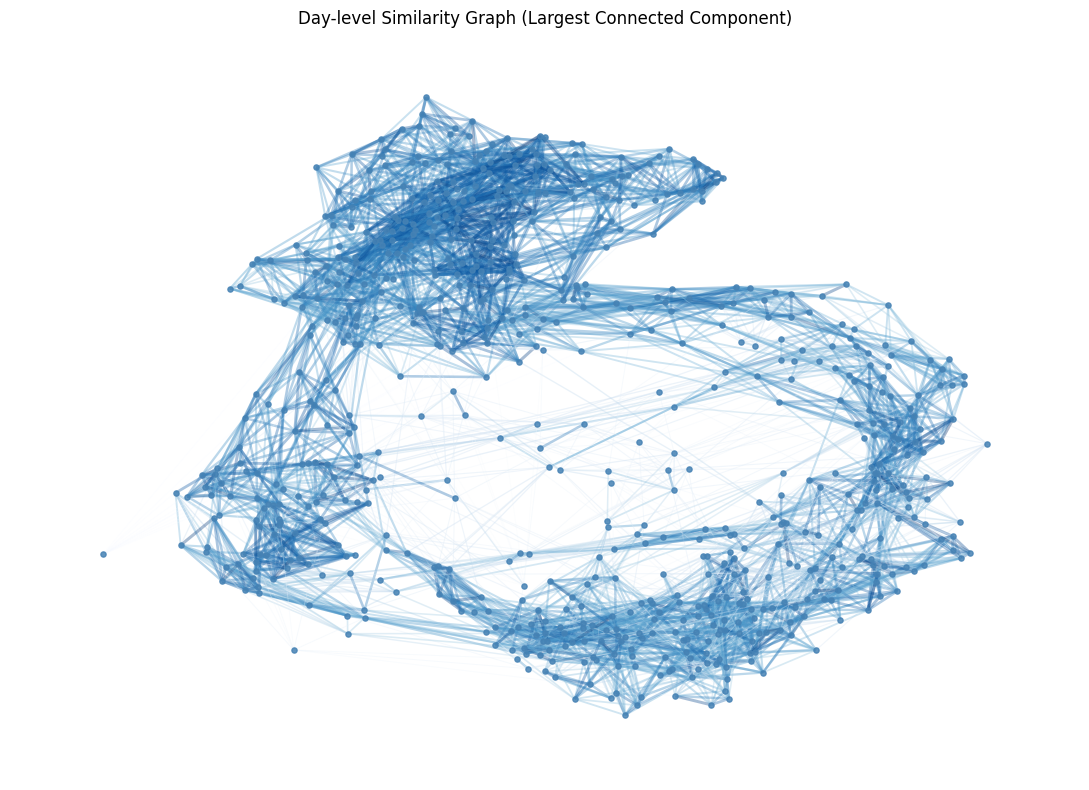

In [20]:
# Graph plot
largest_nodes = max(nx.connected_components(G), key=len)
G_largest_cc = G.subgraph(largest_nodes).copy()
pos = nx.spring_layout(G_largest_cc, seed=RANDOM_SEED, k=0.15)

# Plot
plt.figure(figsize=(11, 8))
weights_plot = [edata["weight"] for _, _, edata in G_largest_cc.edges(data=True)]

nx.draw_networkx_nodes(
    G_largest_cc,
    pos,
    node_size=14,
    node_color="steelblue",
    alpha=0.85
)

nx.draw_networkx_edges(
    G_largest_cc,
    pos,
    width=[0.5 + 1.8 * w for w in weights_plot],
    edge_color=weights_plot,
    edge_cmap=plt.cm.Blues,
    alpha=0.35
)

plt.title("Day-level Similarity Graph (Largest Connected Component)")
plt.axis("off")
plt.tight_layout()
plt.show()

### 3.2 Graph Mining Methods
**Experimnet 1:** Community detection </br>
**Experimnet 2:** Spectral Clustering </br>
**Experimnet 3:** Graph Embeddings</br>

#### Experiment 1: Community Detection (Louvain)

Experiment 1 uses applies Louvain community detection on the generated graph-representation

In [21]:
import networkx.algorithms.community as nx_comm

# Louvain community detection
res = 1.2 # Resolution param to control community size: Tested 0.8, 1.0, 1.2
partition = nx_comm.louvain_communities(
    G_largest_cc,
    weight="weight",
    resolution=res,
    seed=RANDOM_SEED
)

# Modularity value for the partition
modularity_val = nx_comm.modularity(
    G_largest_cc,
    partition,
    weight="weight"
)

# Map each node to its community label
node_to_comm = {}
for cid, nodes in enumerate(partition):
    for n in nodes:
        node_to_comm[n] = cid

print(f"Resolution: {partition}")
print(f"Number of communities: {len(partition)}")
print(f"Modularity: {modularity_val:.4f}")

Resolution: [{384, 387, 6, 390, 391, 10, 397, 17, 18, 19, 403, 405, 24, 409, 25, 27, 411, 30, 31, 32, 34, 419, 39, 424, 426, 54, 55, 440, 62, 67, 68, 69, 454, 73, 74, 81, 82, 88, 89, 90, 97, 102, 111, 368, 373, 375, 376}, {2, 3, 388, 5, 4, 389, 9, 394, 395, 11, 13, 398, 12, 401, 402, 404, 20, 23, 408, 26, 410, 416, 33, 37, 422, 423, 40, 41, 38, 44, 429, 430, 46, 45, 431, 432, 433, 436, 52, 53, 59, 60, 61, 65, 66, 451, 450, 72, 464, 86, 87, 93, 367, 369, 370, 374, 377, 382, 383}, {64, 449, 386, 1, 323, 708, 134, 645, 456, 267, 715, 400, 274, 596, 155, 120, 477, 603, 225, 610, 99, 169, 491, 113, 183, 568, 442, 701}, {514, 516, 520, 522, 523, 524, 529, 530, 531, 535, 536, 47, 48, 75, 76, 80, 83, 95, 96, 103, 107, 109, 110, 114, 115, 118, 124, 125, 128, 129, 130, 131, 135, 139, 396, 144, 145, 146, 150, 152, 153, 156, 157, 158, 412, 160, 417, 418, 163, 164, 165, 167, 425, 437, 438, 439, 443, 444, 446, 452, 453, 457, 458, 459, 460, 461, 465, 466, 467, 468, 472, 474, 475, 479, 480, 482, 487, 

The Louvain partition at resolution of 0.8, 1.0, and 1.2 shows high modularities (0.8159, 0.8177, and 0.8206 respectively), indicating a strong structural coherence in the graph-representaiton.

#### Community Profiles
Behavioral and contextual profiling for the detected communities, used to inspect behavioral separation and interpretability.

In [22]:
# Behavioral and contextual profiling by community
profile_df = data_day.loc[list(G_largest_cc.nodes())].copy()
profile_df["community"] = profile_df.index.map(node_to_comm)

# Behavioral profile: mean, median, std, count for cnt, casual, registered
behavior_profile = (
    profile_df
    .groupby("community")[["cnt", "casual", "registered"]]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)

# Context profile: mean values for contextual features
context_profile = (
    profile_df
    .groupby("community")[["temp", "hum", "windspeed", "weathersit", "season", "workingday", "holiday", "weekday"]]
    .mean()
    .round(3)
)

# Print dataframes
print("Behavioral profile by community:")
display(behavior_profile)
print("\nContext profile by community:")
display(context_profile)

Behavioral profile by community:


cnt                          casual                        \
              mean  median      std count     mean  median     std count   
community                                                                  
0          2274.66  1977.0  1063.13    47   170.23   148.0  137.17    47   
1          2900.20  2425.0  1375.69    59   232.69   163.0  202.50    59   
2          4049.96  4370.0  1659.42    28  1253.89  1273.0  777.76    28   
3          5401.76  5312.0  1403.13    85   856.26   834.0  315.26    85   
4          3951.15  4108.0  2171.55    34  1192.50  1076.5  860.52    34   
5          5967.06  5895.0  1353.15    97   962.74   949.0  230.27    97   
6          5132.35  5043.5  1666.02    52  1687.12  1725.0  739.20    52   
7          4930.62  4669.0  1507.07    82   602.85   536.5  338.04    82   
8          5204.87  5146.0  1385.14    63   543.87   471.0  288.82    63   
9          2211.28  2416.0  1020.84    25   208.28   204.0  146.67    25   
10         4497.51  4367.0  1498.73    43   639.07   630.0  376.30    43   
11         2470.29  2356.5  1163.31    24   695.17   578.5  565.36    24   
12         4828.04  5119.0  2291.72    53  1663.96  1782.0  985.78    53   
13         4865.67  4677.5  1799.46    18  1395.39  1262.0  755.68    18   

          registered                         
                mean  median      std count  
community                                    
0            2104.43  1769.0   970.20    47  
1            2667.51  2147.0  1237.97    59  
2            2796.07  2879.0  1023.44    28  
3            4545.51  4653.0  1171.00    85  
4            2758.65  2709.5  1383.80    34  
5            5004.32  4841.0  1187.27    97  
6            3445.23  3302.0  1058.26    52  
7            4327.77  3921.0  1259.74    82  
8            4661.00  4531.0  1266.30    63  
9            2003.00  2169.0   933.07    25  
10           3858.44  3729.0  1227.13    43  
11           1775.12  1527.0   749.18    24  
12           3164.08  3312.0  1373.64    53  
13           3470.28  3041.0  1185.15    18


Context profile by community:


,temp,hum,windspeed,weathersit,season,workingday,holiday,weekday
community,,,,,,,,
0,0.290,0.692,0.186,2.064,1.191,1.000,0.0,3.617
1,0.283,0.489,0.234,1.017,1.102,1.000,0.0,2.559
2,0.494,0.783,0.169,2.036,2.536,0.000,0.0,0.000
3,0.553,0.566,0.203,1.000,1.835,1.000,0.0,3.388
4,0.468,0.780,0.197,2.118,2.382,0.000,0.0,6.000
5,0.721,0.587,0.166,1.000,3.010,1.000,0.0,3.010
6,0.566,0.610,0.173,1.000,3.038,0.000,0.0,0.000
7,0.543,0.724,0.173,2.000,3.585,0.988,0.0,3.159
8,0.407,0.610,0.165,1.000,3.984,1.000,0.0,3.032


Communities show clear differences in demand level and rider composition (`cnt`, `casual`, `registered`) together with some distinct contextual averages, supporting both behavioral differentiation and practical interpretability.

#### Communities Assignments Visualisation

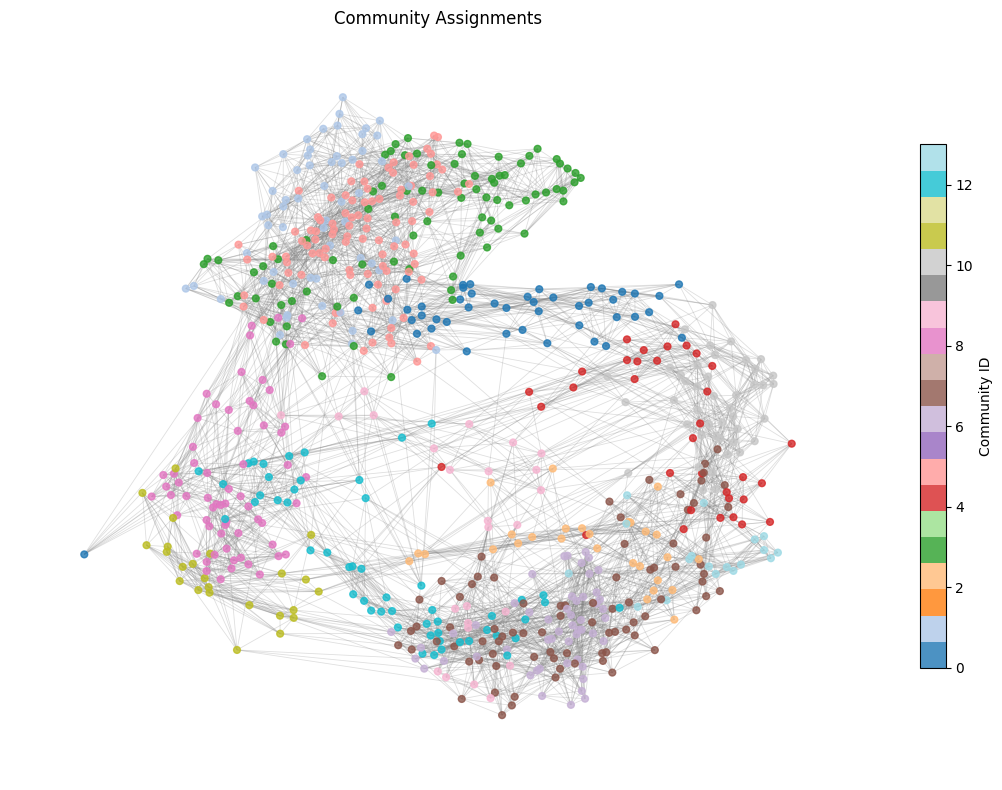

In [23]:
# Community assignment visualization (primary partition)
node_list = list(G_largest_cc.nodes())
community_ids = [node_to_comm[n] for n in node_list]

# Plot
plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(
    G_largest_cc,
    pos,
    edge_color="gray",
    alpha=0.25,
    width=0.6
)

nodes = nx.draw_networkx_nodes(
    G_largest_cc,
    pos,
    nodelist=node_list,
    node_color=community_ids,
    cmap=plt.cm.tab20,
    node_size=24,
    alpha=0.8
)

cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label("Community ID")
plt.title("Community Assignments")
plt.axis("off")
plt.tight_layout()
plt.show()

The community-assignment plot provides visual support for the Louvain partition. Several color groups occupy coherent regions with relatively few links between them. 

### Experiment 1: Discussion

Louvain community detection on the largest connected component identifies stable community structures across tested all resolutions (11 communities at 0.8, 13 at 1.0, and 14 at 1.2), with consistently high modularity (0.8159-0.8206). This supports **H1**, indicating that days with similar weather and calendar context forms coherent graph communities.

The behavioral profiles across communities show a clear differences in the total demand (`cnt`) and rider composition (`casual`, `registered`), supporting **H2**. Several communities are registered-dominated with high demand, while others show higher casual activity and lower registered counts.

Furthermore, the context profiles indicate interpretable regimes; calendar (seasonality, workday, weekend) and weather severity differences, supporting **H3** and suggesting that communities correspond to meaningful day types rather than just arbitrary partitions.

### Experiment 1: Limitations and Improvements
**Limitations**
- Community labels are unlabeled IDs, which should be matched to the specific target variables.
- Results depend on graph construction choices (`k`, similarity kernel, and selected features).
- Analysis is performed on the largest connected components, so a small set of days outside that component is not represented.

**Potential Improvements**
- Add quantitative partition-stability checks across random seeds/resolution values.
- Compare Louvain with an alternative community algorithm (for example, Leiden) to test robustness of findings.

## 4. Module 3 — Pattern / Text Mining

In [24]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
